# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import gymnasium as gym
import random
import pickle
import requests
import dash
import shap
import plotly.express as px

from dash import dcc, html
from dash.dependencies import Input, Output
from flask import Flask, request, jsonify
from collections import defaultdict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import tensorflow as tf
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Dropout
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.models import Model
from sklearn.ensemble import StackingRegressor

# Load Dataset

In [2]:
df = pd.read_csv("kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,city,state,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,Adjuntas,Puerto Rico,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,Adjuntas,Puerto Rico,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,Juana Diaz,Puerto Rico,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,Ponce,Puerto Rico,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,Mayaguez,Puerto Rico,7503


In [3]:
df.shape

(21613, 23)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# Visualize Distribution of 'price'

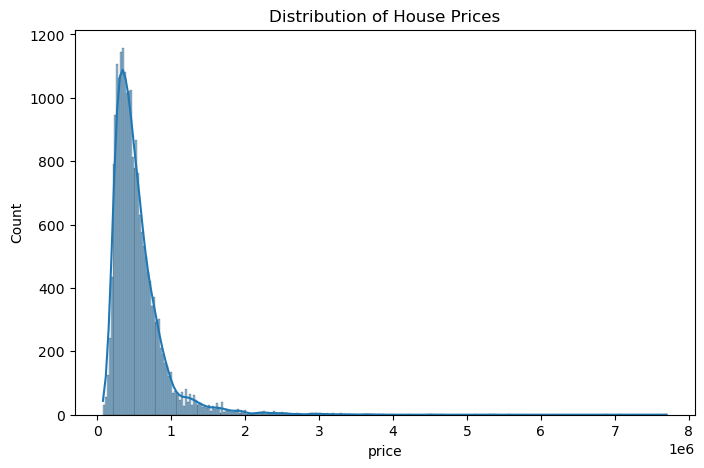

Mean: 540182.1587933188
Median: 450000.0


In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

print("Mean:", df['price'].mean())
print("Median:", df['price'].median())

# The distribution is right skewed

### - Mean > Median → confirms skewness

### - Few very high-priced houses → outliers present

# Correlation Heatmap

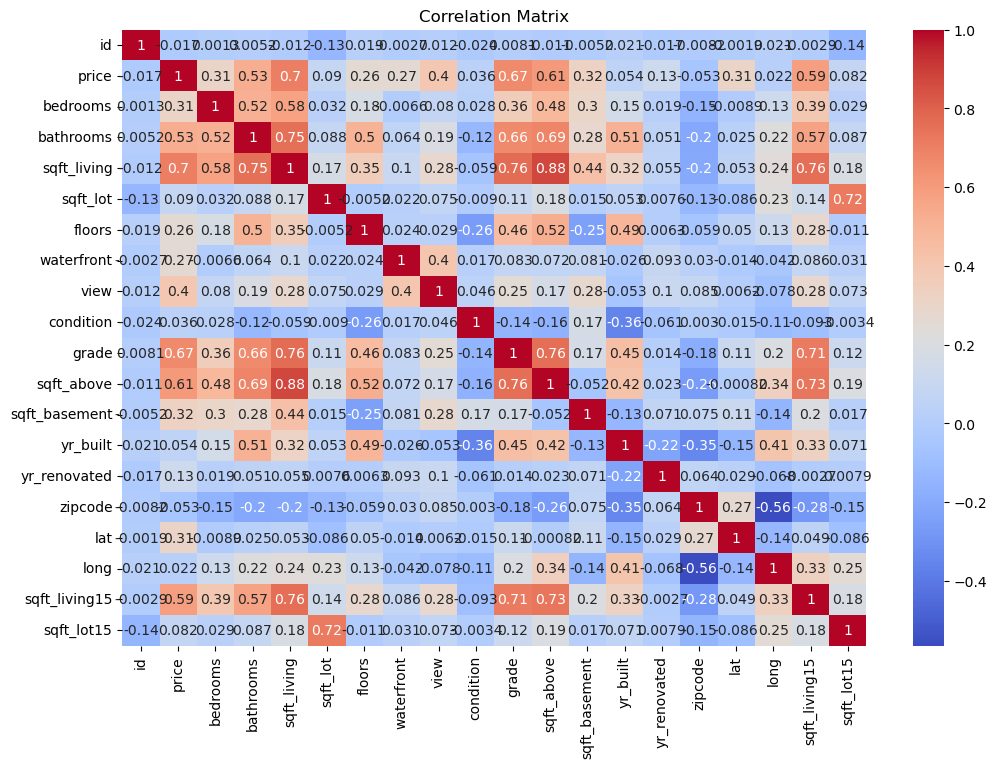

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Price vs Sqft Living

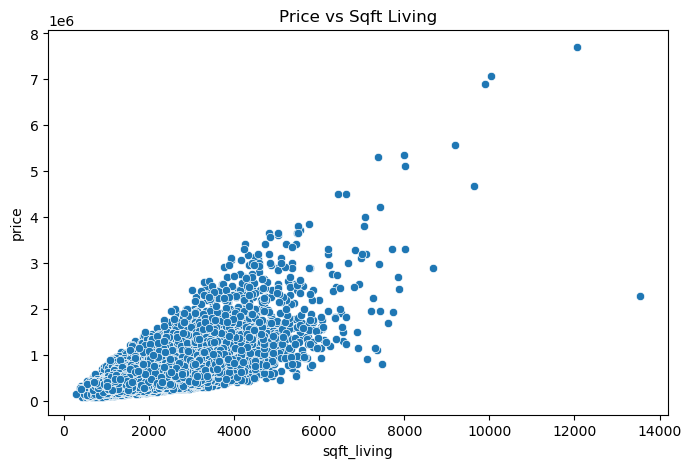

Correlation: 0.7020437212325275


In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title("Price vs Sqft Living")
plt.show()

print("Correlation:",
      df['sqft_living'].corr(df['price']))

# Price vs Bedrooms & Bathrooms

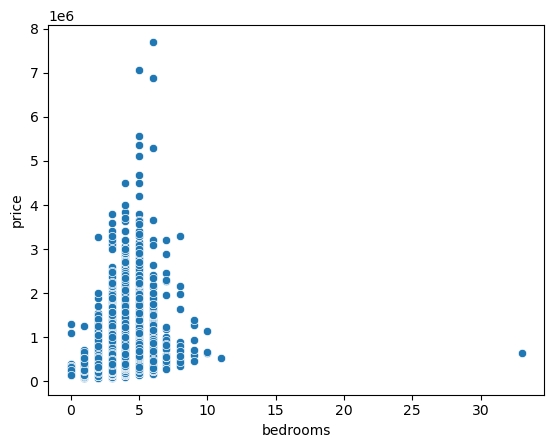

In [8]:
sns.scatterplot(x='bedrooms', y='price', data=df)
plt.show()

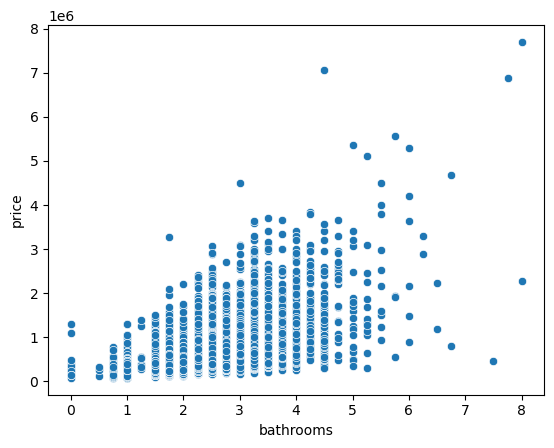

In [9]:
sns.scatterplot(x='bathrooms', y='price', data=df)
plt.show()

# Waterfront Impact

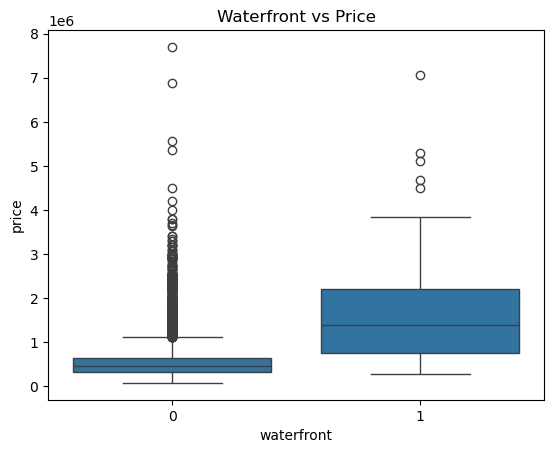

In [10]:
sns.boxplot(x='waterfront', y='price', data=df)
plt.title("Waterfront vs Price")
plt.show()

# Price Evolution Over Time (date)

In [11]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

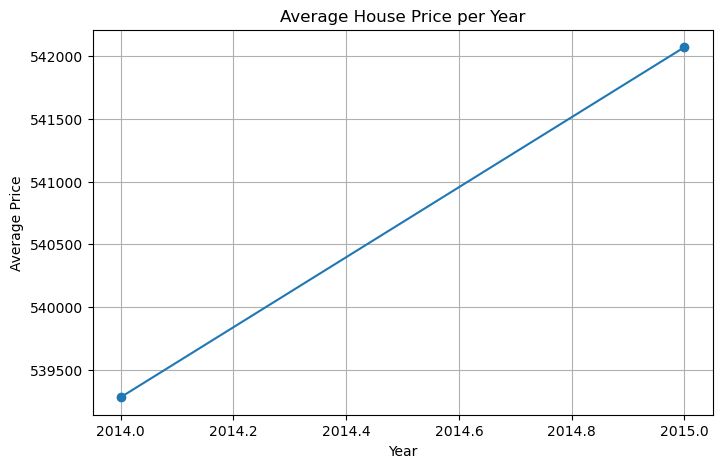

In [13]:
# Convert date column to datetime and extract year
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year

# Calculate yearly average price
yearly_price = df.groupby('year')['price'].mean()

# Plot
plt.figure(figsize=(8,5))
yearly_price.plot(marker='o')

plt.title("Average House Price per Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)

plt.show()

# Median Price by City

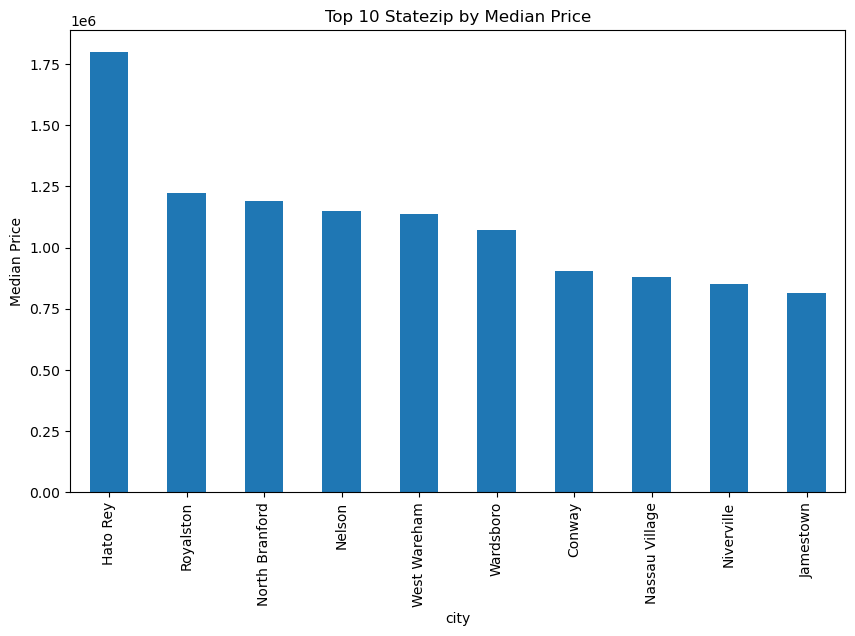

In [14]:
city_median = df.groupby('city')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(10,6))
city_median.head(10).plot(kind='bar')
plt.title("Top 10 Statezip by Median Price")
plt.ylabel("Median Price")
plt.show()

# Distribution Across statezip

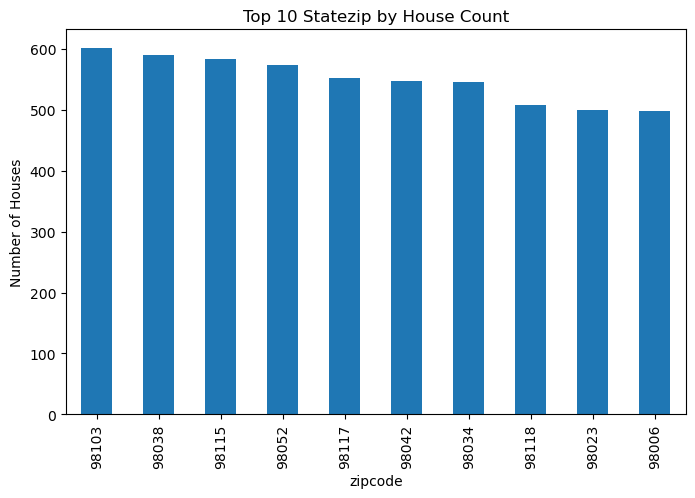

In [15]:
statezip_count = df['zipcode'].value_counts().head(10)

plt.figure(figsize=(8,5))
statezip_count.plot(kind='bar')
plt.title("Top 10 Statezip by House Count")
plt.ylabel("Number of Houses")
plt.show()

# Price vs Condition (Boxplot)

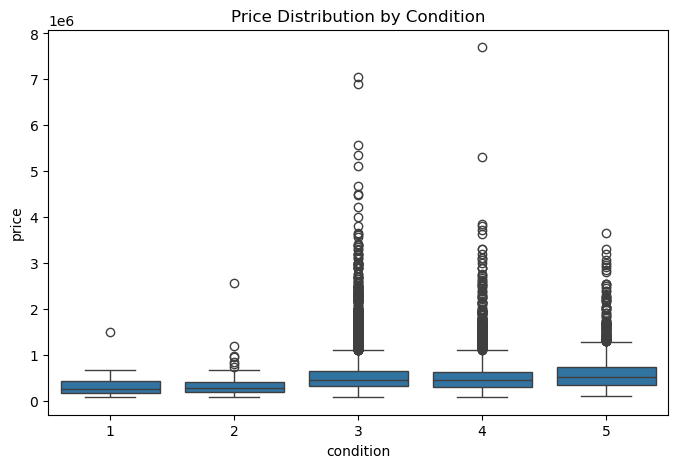

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='condition', y='price', data=df)
plt.title("Price Distribution by Condition")
plt.show()

# Pair Plot (Multiple Feature Relationships)

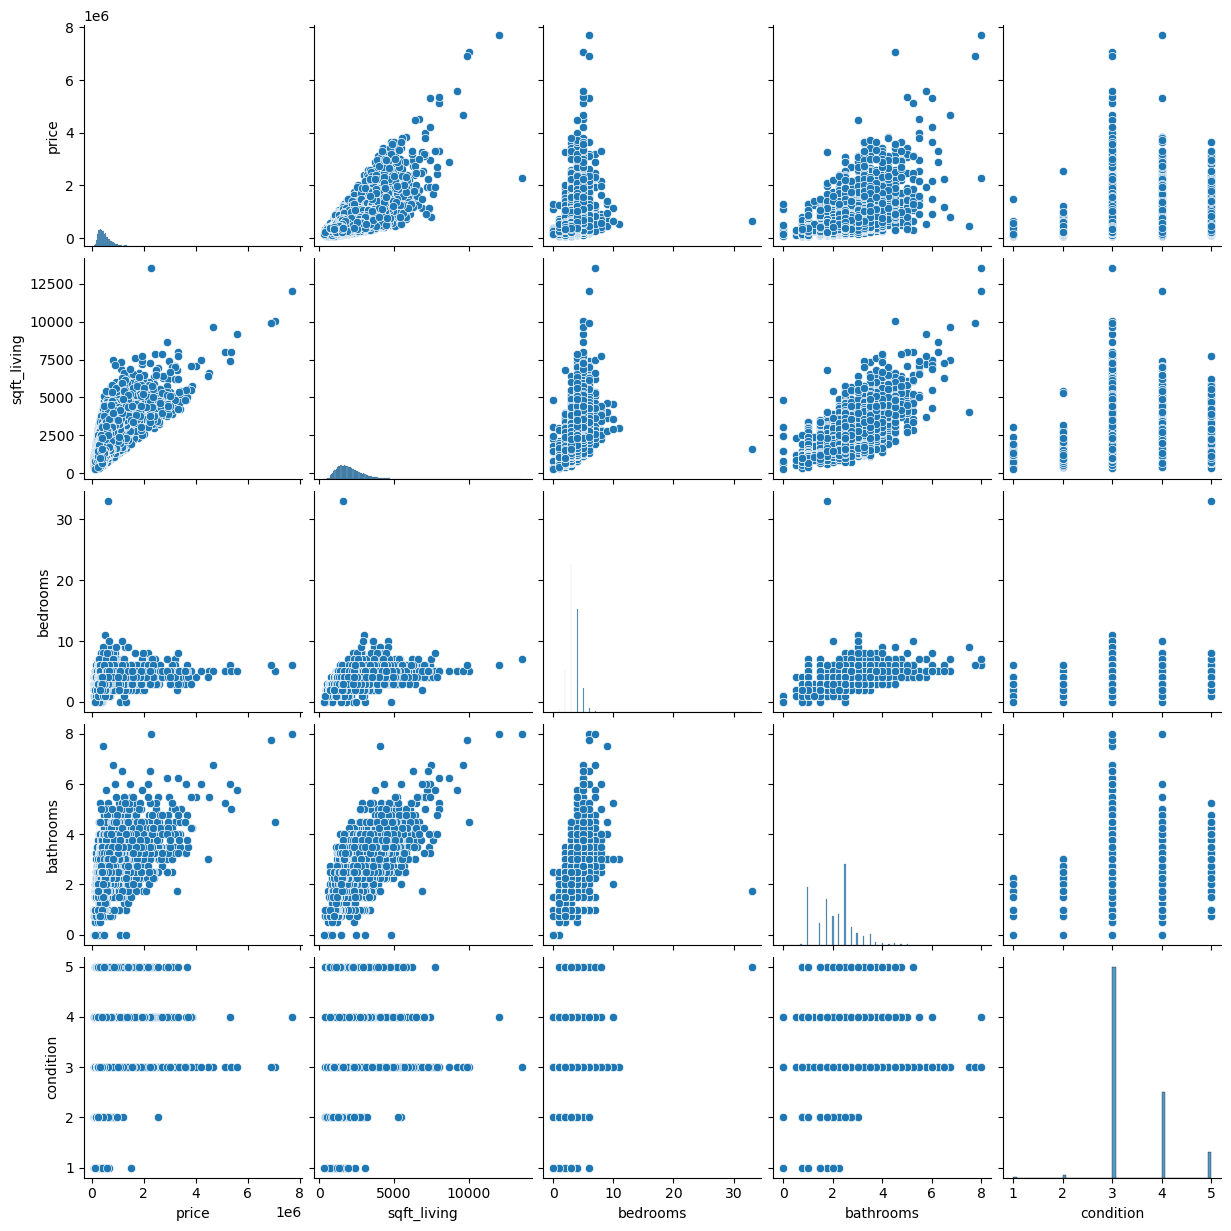

In [17]:
sns.pairplot(df[['price','sqft_living','bedrooms','bathrooms','condition']])
plt.show()

# Impact of Renovation Year on Price

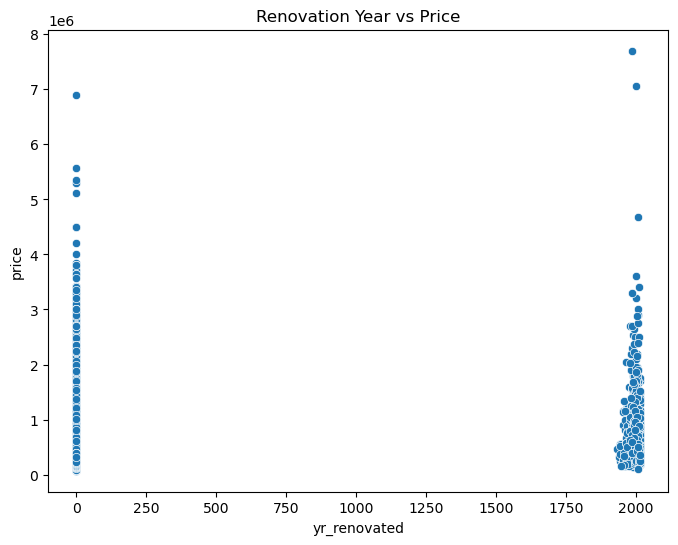

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='yr_renovated', y='price', data=df)
plt.title("Renovation Year vs Price")
plt.show()

# Remove 0 values

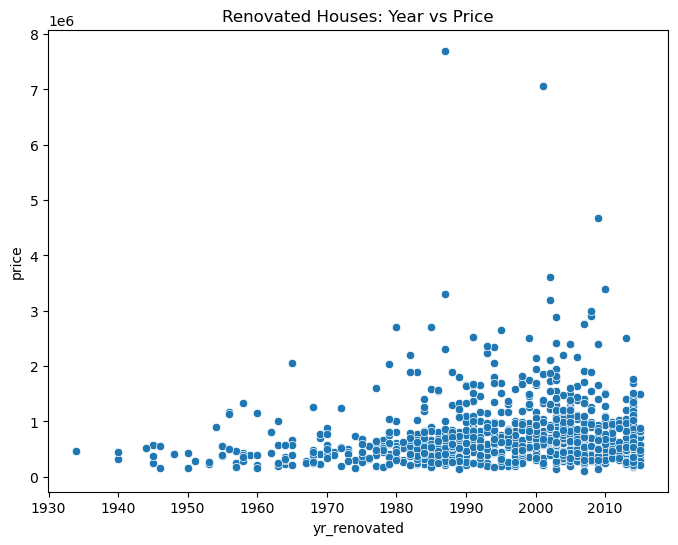

In [19]:
renovated = df[df['yr_renovated'] != 0]

plt.figure(figsize=(8,6))
sns.scatterplot(x='yr_renovated', y='price', data=renovated)
plt.title("Renovated Houses: Year vs Price")
plt.show()

# Average Price Per City

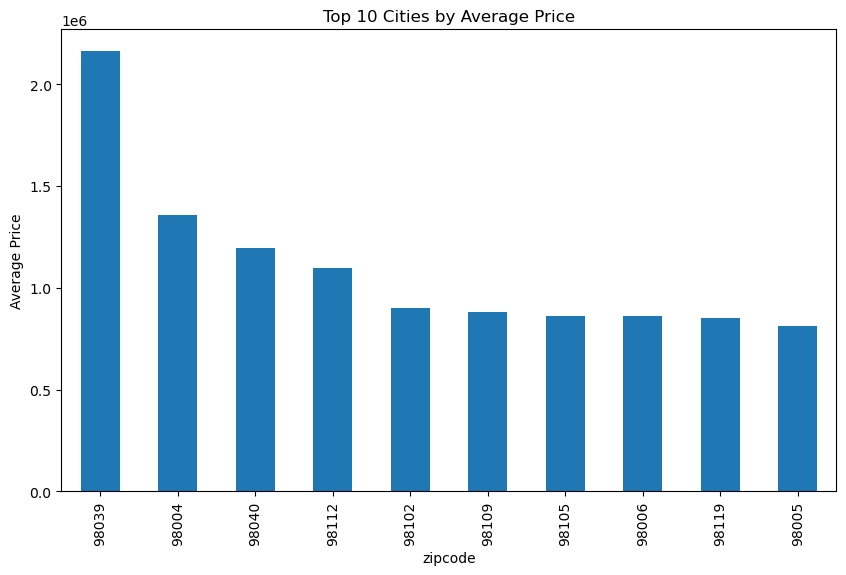

Highest Average Price City: 98039


In [20]:
city_avg = df.groupby('zipcode')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
city_avg.head(10).plot(kind='bar')
plt.title("Top 10 Cities by Average Price")
plt.ylabel("Average Price")
plt.show()

print("Highest Average Price City:", city_avg.idxmax())

# Most Common House Types (Bedrooms + Bathrooms)

In [21]:
pivot = pd.pivot_table(df,
                       values='price',
                       index='bedrooms',
                       columns='bathrooms',
                       aggfunc='count')

print(pivot)

bathrooms  0.00  0.50  0.75    1.00  1.25   1.50    1.75    2.00    2.25  \
bedrooms                                                                   
0           7.0   NaN   1.0     1.0   NaN    1.0     NaN     NaN     NaN   
1           3.0   1.0  27.0   138.0   2.0   12.0     4.0     6.0     4.0   
2           NaN   2.0  26.0  1558.0   3.0  294.0   304.0   216.0   118.0   
3           NaN   NaN  16.0  1780.0   4.0  829.0  1870.0  1048.0  1082.0   
4           NaN   1.0   2.0   325.0   NaN  254.0   719.0   525.0   709.0   
5           NaN   NaN   NaN    43.0   NaN   48.0   134.0   110.0   116.0   
6           NaN   NaN   NaN     6.0   NaN    6.0    16.0    24.0    15.0   
7           NaN   NaN   NaN     1.0   NaN    2.0     NaN     NaN     3.0   
8           NaN   NaN   NaN     NaN   NaN    NaN     NaN     NaN     NaN   
9           NaN   NaN   NaN     NaN   NaN    NaN     NaN     NaN     NaN   
10          NaN   NaN   NaN     NaN   NaN    NaN     NaN     1.0     NaN   
11          

In [22]:
df['house_type'] = df['bedrooms'].astype(str) + "BHK-" + df['bathrooms'].astype(str) + "Bath"

print(df['house_type'].value_counts().head(10))

house_type
4BHK-2.5Bath     2502
3BHK-2.5Bath     2357
3BHK-1.75Bath    1870
3BHK-1.0Bath     1780
2BHK-1.0Bath     1558
3BHK-2.25Bath    1082
3BHK-2.0Bath     1048
3BHK-1.5Bath      829
4BHK-1.75Bath     719
4BHK-2.25Bath     709
Name: count, dtype: int64


# Compare Price Trends Across States

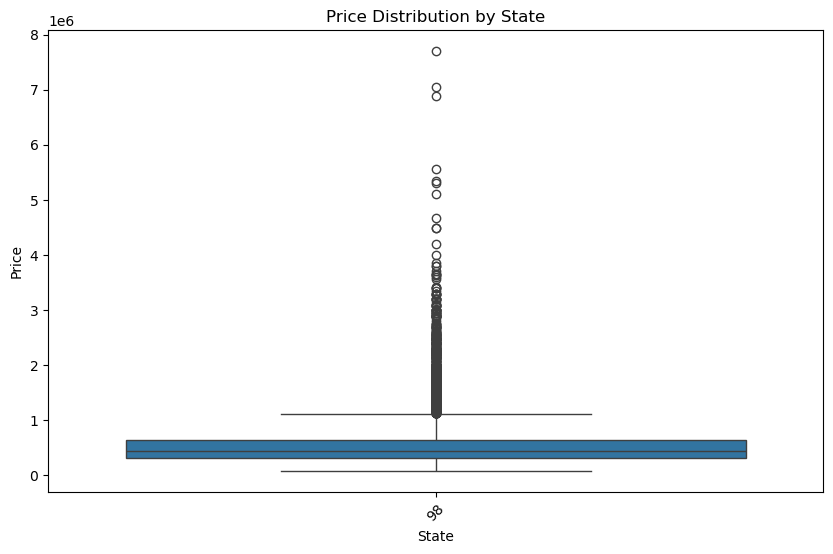

In [23]:
# Create state column from statezip
df['state'] = df['zipcode'].astype(str).str[:2]

plt.figure(figsize=(10,6))
sns.boxplot(x='state', y='price', data=df)

plt.xticks(rotation=45)
plt.title("Price Distribution by State")
plt.xlabel("State")
plt.ylabel("Price")

plt.show()

# Feature Selection

In [24]:
# Target variable
y = df['price']

# Features (remove price column)
X = df.drop(['price'], axis=1)

# Keep only numeric columns (very important)
X = X.select_dtypes(include=['int64', 'float64'])

In [25]:
# Remove rows where price is NaN
df = df.dropna(subset=['price'])

# Define X and y again
y = df['price']
X = df.drop(['price'], axis=1)

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Remove any remaining NaN values from X
X = X.fillna(0)

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)

Selected Features: Index(['waterfront', 'view', 'grade', 'lat', 'long'], dtype='object')


In [26]:
print(X.head())
print(y.head())

           id  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  7129300520         3       1.00         1180      5650     1.0           0   
1  6414100192         3       2.25         2570      7242     2.0           0   
2  5631500400         2       1.00          770     10000     1.0           0   
3  2487200875         4       3.00         1960      5000     1.0           0   
4  1954400510         3       2.00         1680      8080     1.0           0   

   view  condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
0     0          3      7        1180              0      1955             0   
1     0          3      7        2170            400      1951          1991   
2     0          3      6         770              0      1933             0   
3     0          5      7        1050            910      1965             0   
4     0          3      8        1680              0      1987             0   

   zipcode      lat     long  sq

In [27]:
print(df.tail(5))

               id       date     price  bedrooms  bathrooms  sqft_living  \
21608   263000018 2014-05-21  360000.0         3       2.50         1530   
21609  6600060120 2015-02-23  400000.0         4       2.50         2310   
21610  1523300141 2014-06-23  402101.0         2       0.75         1020   
21611   291310100 2015-01-16  400000.0         3       2.50         1600   
21612  1523300157 2014-10-15  325000.0         2       0.75         1020   

       sqft_lot  floors  waterfront  view  ...  zipcode      lat     long  \
21608      1131     3.0           0     0  ...    98103  47.6993 -122.346   
21609      5813     2.0           0     0  ...    98146  47.5107 -122.362   
21610      1350     2.0           0     0  ...    98144  47.5944 -122.299   
21611      2388     2.0           0     0  ...    98027  47.5345 -122.069   
21612      1076     2.0           0     0  ...    98144  47.5941 -122.299   

       sqft_living15        city  state  sqft_lot15  year  month  \
21608       

# Check Dataset Structure


In [28]:
# Basic info
df.info()

# Statistical summary
df.describe()

# Missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[ns]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   2161

id                0
date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
city             16
state             0
sqft_lot15        0
year              0
month             0
house_type        0
dtype: int64

# Handle Missing Values

### - Numeric columns → fill with median

In [29]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → fill with mode

In [30]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Convert Categorical → Numerical
### ✔ One-Hot Encoding (Best)

In [31]:
df = pd.get_dummies(df, columns=['zipcode', 'city', 'state'], drop_first=True)

In [32]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

# Apply on important columns
for col in ['price', 'sqft_living', 'bedrooms']:
    df = remove_outliers(df, col)

# Feature Scaling

In [33]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

# Remove Duplicate Records

In [34]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("After removal:", df.duplicated().sum())

Duplicate rows: 0
After removal: 0


# Handle Unrealistic Values (IQR Method)

In [35]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Capping instead of removing
    df[col] = df[col].clip(lower, upper)
    return df

# Apply on important columns
for col in ['price', 'sqft_lot']:
    df = cap_outliers(df, col)

# Create Property Age Feature

In [36]:
# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Create property age (assuming 'yr_built' exists)
df['property_age'] = df['date'].dt.year - df['yr_built']

# Train-Test Split

In [37]:
# Define features & target
y = df['price']
X = df.drop(['price'], axis=1)

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (15743, 19)
Test shape: (3936, 19)


# Correlation + Multicollinearity Check
### ✔ Correlation Heatmap

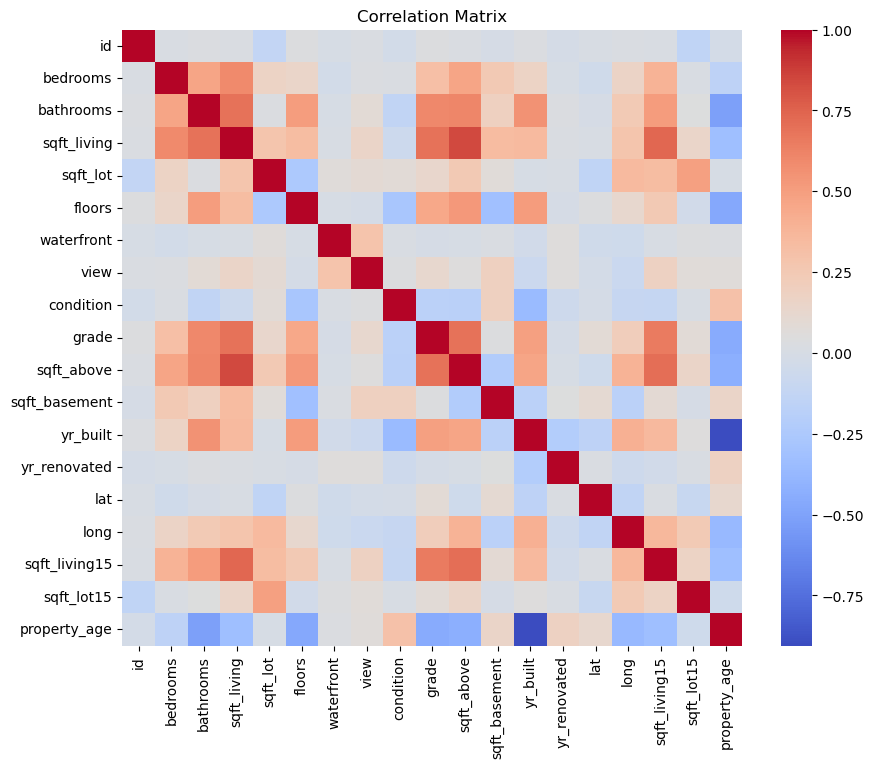

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [39]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19679 entries, 0 to 21612
Columns: 813 entries, id to property_age
dtypes: bool(789), datetime64[ns](1), float64(20), int32(2), object(1)
memory usage: 18.4+ MB


# Feature Scaling

In [40]:
print(df.isnull().sum())

id                    0
date                  0
price                 0
bedrooms              0
bathrooms             0
                     ..
city_Yabucoa          0
city_Yarmouth         0
city_Yarmouth Port    0
city_Yauco            0
property_age          0
Length: 813, dtype: int64


In [41]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

# Convert waterfront & view to Binary

In [42]:
# If already 0/1, this is safe
df['waterfront'] = df['waterfront'].apply(lambda x: 1 if x > 0 else 0)
df['view'] = df['view'].apply(lambda x: 1 if x > 0 else 0)

# Convert condition to Ordinal

In [43]:
# Assuming condition values are 1–5
condition_map = {
    1: 1,  # Poor
    2: 2,
    3: 3,
    4: 4,
    5: 5   # Excellent
}

df['condition'] = df['condition'].map(condition_map)

# Polynomial Features

In [44]:
poly = PolynomialFeatures(degree=2, include_bias=False)

# Select important features
poly_features = df[['sqft_living', 'bedrooms', 'bathrooms']]

poly_data = poly.fit_transform(poly_features)

# Convert to DataFrame
poly_df = pd.DataFrame(poly_data, columns=poly.get_feature_names_out())

# Merge with original dataset
df = pd.concat([df.reset_index(drop=True), poly_df.reset_index(drop=True)], axis=1)

# PCA (Dimensionality Reduction)

In [45]:
print(X.isnull().sum().sum())

0


In [46]:
# Step 1: Select numeric columns
X = df.select_dtypes(include=['int64', 'float64'])

# Step 2: Remove columns with ALL NaN values
X = X.dropna(axis=1, how='all')

# Step 3: Fill remaining NaN values
X = X.fillna(X.mean())

# Step 4: Replace infinite values (VERY IMPORTANT)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# Step 5: Remove constant columns (same value everywhere)
X = X.loc[:, X.nunique() > 1]

# Step 6: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 7: Final safety check (IMPORTANT)
X_scaled = np.nan_to_num(X_scaled)

# Step 8: Apply PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (19679, 28)
Reduced shape: (19679, 18)


# Price per Square Foot

In [47]:
# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Create feature safely
df['price_per_sqft'] = df['price'] / df['sqft_living']
df['price_per_sqft'] = df['price_per_sqft'].replace([np.inf, -np.inf], 0)

# Basement Binary Feature

In [48]:
df['has_basement'] = df['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)

# Interaction Feature

In [49]:
df['sqft_bedrooms_interaction'] = df['sqft_living'] * df['bedrooms']

# Renovation Feature

In [50]:
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

# K-Means Clustering (City-wise)

In [51]:
# Clean column names
df.columns = df.columns.str.strip()

# Use only price (NO city/zipcode needed)
X = df[['price']].dropna()

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# Show result
print(df[['price', 'cluster']].head())

      price  cluster
0 -1.238408        0
1  0.336385        1
2 -1.447151        0
3  0.665194        1
4  0.196891        1


# Create Decade Feature

In [52]:
df = pd.read_csv("kc_house_data.csv")

# Fix column names
df.columns = df.columns.str.strip()

# Convert yr_built to numeric
df['yr_built'] = pd.to_numeric(df['yr_built'], errors='coerce')

# Create decade feature
df['decade_built'] = (df['yr_built'] // 10) * 10

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,city,state,sqft_lot15,decade_built
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,1955,0,98178,47.5112,-122.257,1340,Adjuntas,Puerto Rico,5650,1950
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,1951,1991,98125,47.7210,-122.319,1690,Adjuntas,Puerto Rico,7639,1950
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,1933,0,98028,47.7379,-122.233,2720,Juana Diaz,Puerto Rico,8062,1930
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,1965,0,98136,47.5208,-122.393,1360,Ponce,Puerto Rico,5000,1960
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,1987,0,98074,47.6168,-122.045,1800,Mayaguez,Puerto Rico,7503,1980


In [53]:
# Ratio of land to living space
df['house_density'] = df['sqft_lot'] / df['sqft_living']

In [54]:
import numpy as np

df['log_price'] = np.log(df['price'])

In [55]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract year of sale
df['sale_year'] = df['date'].dt.year

# Calculate age
df['house_age'] = df['sale_year'] - df['yr_built']

In [56]:
df['price_growth_rate'] = (df['price'] / df['house_age']).replace([np.inf, -np.inf], 0)

# Task 1: Total Rooms Feature

In [57]:
df = pd.read_csv("kc_house_data.csv")
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

# Task 2: One-Hot Encoding (Categorical)

In [58]:
df = pd.get_dummies(df, columns=['zipcode'], drop_first=True)

# Task 3: House Desirability Score
### - Step 1: Normalize features

In [59]:
scaler = MinMaxScaler()

df[['view_norm', 'condition_norm', 'sqft_living_norm']] = scaler.fit_transform(
    df[['view', 'condition', 'sqft_living']]
)

### - Step 2: Create score

In [60]:
df['desirability_score'] = (
    df['view_norm'] +
    df['condition_norm'] +
    df['sqft_living_norm']
) / 3

# Task 4: Convert View to Ordinal

In [61]:
df['view_ordinal'] = df['view']


In [62]:
view_map = {
    0: 0,   # no view
    1: 1,   # partial
    2: 2,   # good
    3: 3,   # excellent
    4: 3    # top level treated as excellent
}

df['view_ordinal'] = df['view'].map(view_map)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,view_norm,condition_norm,sqft_living_norm,desirability_score,view_ordinal
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,False,True,False,False,False,0.0,0.5,0.067170,0.189057,0
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,False,False,False,False,False,0.0,0.5,0.172075,0.224025,0
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,False,False,False,False,False,0.0,0.5,0.036226,0.178742,0
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,False,False,False,False,False,0.0,1.0,0.126038,0.375346,0
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,False,False,False,False,False,0.0,0.5,0.104906,0.201635,0


# Task 5: Price Categories

In [63]:
df['price_category'] = pd.qcut(
    df['price'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,view_norm,condition_norm,sqft_living_norm,desirability_score,view_ordinal,price_category
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,True,False,False,False,0.0,0.5,0.067170,0.189057,0,Low
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,False,False,False,False,0.0,0.5,0.172075,0.224025,0,Medium
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,False,False,False,False,0.0,0.5,0.036226,0.178742,0,Low
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,False,False,False,False,0.0,1.0,0.126038,0.375346,0,High
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,False,False,False,False,0.0,0.5,0.104906,0.201635,0,Medium


### - Step 0: Prepare Data

In [64]:
# Features (remove target and non-useful columns)
X = df.drop(['price', 'price_category'], axis=1, errors='ignore')

# Target
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Task 1: Linear Regression

In [65]:
print("Original df shape:", df.shape)
print("Columns:", df.columns)
print(df.head())

Original df shape: (21613, 98)
Columns: Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat',
       'long', 'sqft_living15', 'city', 'state', 'sqft_lot15', 'total_rooms',
       'zipcode_98002', 'zipcode_98003', 'zipcode_98004', 'zipcode_98005',
       'zipcode_98006', 'zipcode_98007', 'zipcode_98008', 'zipcode_98010',
       'zipcode_98011', 'zipcode_98014', 'zipcode_98019', 'zipcode_98022',
       'zipcode_98023', 'zipcode_98024', 'zipcode_98027', 'zipcode_98028',
       'zipcode_98029', 'zipcode_98030', 'zipcode_98031', 'zipcode_98032',
       'zipcode_98033', 'zipcode_98034', 'zipcode_98038', 'zipcode_98039',
       'zipcode_98040', 'zipcode_98042', 'zipcode_98045', 'zipcode_98052',
       'zipcode_98053', 'zipcode_98055', 'zipcode_98056', 'zipcode_98058',
       'zipcode_98059', 'zipcode_98065', 'zipcode_98070', 'zipcode

In [66]:
# Remove missing target values
df = df.dropna(subset=['price'])

# Define X and y
X = df.drop(['price', 'price_category', 'id'], axis=1, errors='ignore')
y = df['price']

# Keep numeric
X = X.select_dtypes(include=['int64', 'float64'])

# Handle infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# Handle missing values
X = X.fillna(X.mean())

print("Final Shape:", X.shape)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
lr = LinearRegression()
lr.fit(X_train, y_train)

# Evaluate

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Final Shape: (21613, 23)
MAE: 128250.82450590792
R² Score: 0.6971915628379062


In [67]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,view_norm,condition_norm,sqft_living_norm,desirability_score,view_ordinal,price_category
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,True,False,False,False,0.0,0.5,0.067170,0.189057,0,Low
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,False,False,False,False,0.0,0.5,0.172075,0.224025,0,Medium
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,False,False,False,False,0.0,0.5,0.036226,0.178742,0,Low
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,False,False,False,False,0.0,1.0,0.126038,0.375346,0,High
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,False,False,False,False,0.0,0.5,0.104906,0.201635,0,Medium


# Task 2: Decision Tree Regressor

In [68]:
dt = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))

# Cross-validation
cv_scores = cross_val_score(dt, X, y, cv=5)
print("CV Score:", cv_scores.mean())

MAE: 121854.8748909011
R2 Score: 0.6861325776648474
CV Score: 0.7003401995515135


# Task 3: Random Forest + Grid Search

In [69]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Best Params:", grid.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 50}
MAE: 79676.13297558545
R2 Score: 0.8397155989613778


# Task 4: Gradient Boosting

In [70]:
gb = GradientBoostingRegressor(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("R2 Score:", r2_score(y_test, y_pred_gb))

MAE: 81861.71348877106
R2 Score: 0.8493893351272823


# Task 5: XGBoost

In [71]:
xgb = XGBRegressor(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

MAE: 73558.63389139487
R2 Score: 0.8522265412726036


# Task 1: Compare Ensemble Models

In [72]:
# Models
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, random_state=42)

# Train
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Predict
y_rf = rf.predict(X_test)
y_gb = gb.predict(X_test)
y_xgb = xgb.predict(X_test)

# R2 Scores
print("RF R2:", r2_score(y_test, y_rf))
print("GB R2:", r2_score(y_test, y_gb))
print("XGB R2:", r2_score(y_test, y_xgb))

# Cross-validation
print("RF CV:", cross_val_score(rf, X, y, cv=5).mean())
print("GB CV:", cross_val_score(gb, X, y, cv=5).mean())
print("XGB CV:", cross_val_score(xgb, X, y, cv=5).mean())

RF R2: 0.8530549740696541
GB R2: 0.8493893351272823
XGB R2: 0.8319084372476505
RF CV: 0.8768138102126031
GB CV: 0.8602464117554047
XGB CV: 0.8738751621052392


In [73]:
# Models
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, random_state=42)

# Train
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Predict
y_rf = rf.predict(X_test)
y_gb = gb.predict(X_test)
y_xgb = xgb.predict(X_test)

# mean_absolute_error
print("RF MAE:", mean_absolute_error(y_test, y_rf))
print("GB MAE:", mean_absolute_error(y_test, y_gb))
print("XGB MAE:", mean_absolute_error(y_test, y_xgb))

RF MAE: 73146.19262479208
GB MAE: 81861.71348877106
XGB MAE: 73378.65763611786


#  Task 2: Support Vector Regression (SVR)

In [75]:
# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
svr = SVR(kernel='rbf', C=100)

svr.fit(X_train_scaled, y_train)

y_svr = svr.predict(X_test_scaled)

print("SVR MAE:", mean_absolute_error(y_test, y_svr))
print("SVR R2:", r2_score(y_test, y_svr))

SVR MAE: 191351.99756093297
SVR R2: 0.1032516762615705


# Task 3: KNN Regressor

In [76]:
# Try different k values
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

y_knn = knn.predict(X_test)

print("KNN R2:", r2_score(y_test, y_knn))

KNN R2: 0.5035819675409141


# Task 4: Artificial Neural Network (ANN)

In [77]:
ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)

ann.fit(X_train, y_train)

y_ann = ann.predict(X_test)

print("ANN R2:", r2_score(y_test, y_ann))

ANN R2: 0.6411470585041257


C:\Users\shamb\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Task 5: Lasso Regression (Feature Selection)

In [78]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# Predict
y_lasso = lasso.predict(X_test_scaled)

print("Lasso R2:", r2_score(y_test, y_lasso))

Lasso R2: 0.6971914577542779


C:\Users\shamb\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.165e+14, tolerance: 2.262e+11
  model = cd_fast.enet_coordinate_descent(


# Task 1: Ridge Regression (L2 Regularization)

In [79]:
# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Prediction
y_ridge = ridge.predict(X_test_scaled)

print("Ridge R2:", r2_score(y_test, y_ridge))

Ridge R2: 0.6971863609787099


# Task 2: CatBoost Model

In [80]:
cat = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, verbose=0)

cat.fit(X_train, y_train)

y_cat = cat.predict(X_test)

print("CatBoost R2:", r2_score(y_test, y_cat))
print("CatBoost MAE:", mean_absolute_error(y_test, y_cat))

CatBoost R2: 0.8838018852365688
CatBoost MAE: 76308.61022223493


# Task 3: AutoML

In [81]:
model = RandomForestRegressor()

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

auto = GridSearchCV(model, params, cv=3)
auto.fit(X_train, y_train)

print("Best Model Params:", auto.best_params_)

Best Model Params: {'max_depth': 10, 'n_estimators': 100}


# Task 4: Model Comparison

In [82]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name} -> RMSE: {rmse}, MAE: {mae}, R2: {r2}")

# Evaluate all
evaluate("Random Forest", y_test, y_rf)
evaluate("XGBoost", y_test, y_xgb)
evaluate("CatBoost", y_test, y_cat)
evaluate("Ridge", y_test, y_ridge)

Random Forest -> RMSE: 149133.5669489267, MAE: 73146.19262479208, R2: 0.8530549740696541
XGBoost -> RMSE: 159503.75730985368, MAE: 73378.65763611786, R2: 0.8319084372476505
CatBoost -> RMSE: 132616.48153974672, MAE: 76308.61022223493, R2: 0.8838018852365688
Ridge -> RMSE: 214084.72264097998, MAE: 128248.88936671929, R2: 0.6971863609787099


# Task 5: GridSearchCV

In [83]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, n_jobs=-1)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_best = best_model.predict(X_test)

print("Best Params:", grid.best_params_)
print("Final R2:", r2_score(y_test, y_best))

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Final R2: 0.8589892825971877


# Task 1: K-Fold Cross Validation

In [84]:
model = RandomForestRegressor(random_state=42)

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross-validation scores:", scores)
print("Average R2:", scores.mean())

Cross-validation scores: [0.8762597  0.88481889 0.8772275  0.86791343 0.87784953]
Average R2: 0.8768138102126031


# Task 2: Feature Selection (RFE vs Lasso)

In [85]:
rfe = RFE(LinearRegression(), n_features_to_select=5)
rfe.fit(X, y)

print("RFE Selected Features:", X.columns[rfe.support_])

RFE Selected Features: Index(['waterfront', 'view', 'condition', 'lat', 'desirability_score'], dtype='object')


# lasso

In [86]:
rfe = RFE(LinearRegression(), n_features_to_select=5)
rfe.fit(X, y)

print("RFE Selected Features:", X.columns[rfe.support_])

RFE Selected Features: Index(['waterfront', 'view', 'condition', 'lat', 'desirability_score'], dtype='object')


# Task 3: RandomizedSearchCV

In [87]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}


# Task 4: Residual Plot

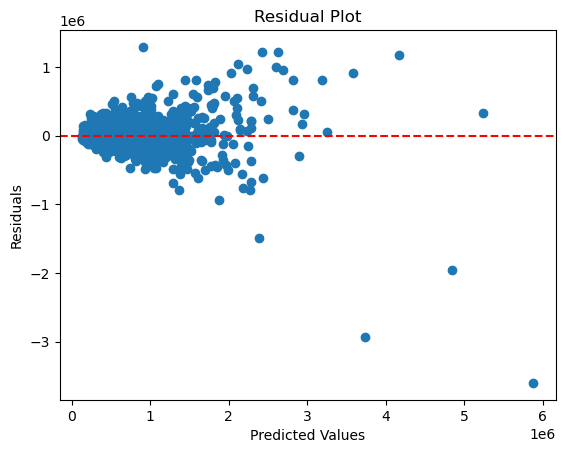

In [88]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the model
rf = RandomForestRegressor(random_state=42)

# 2. Fit the model on training data
rf.fit(X_train, y_train)

# 3. Predict on test data
y_pred = rf.predict(X_test)

# 4. Calculate residuals
residuals = y_test - y_pred

# 5. Plot residuals
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


# Task 5: Learning Curve

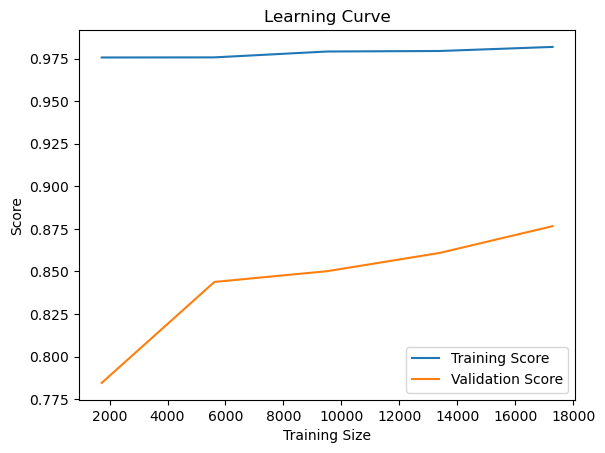

In [89]:
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(),
    X, y,
    cv=5
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

# Train Multiple Models

In [90]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost':XGBRegressor(n_estimators=200, random_state=42, eval_metric='rmse')
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Training predictions
    y_train_pred = model.predict(X_train)
    # Testing predictions
    y_test_pred = model.predict(X_test)
    
    # Metrics
    metrics = {
        'Model': name,
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train_MAE': mean_absolute_error(y_train, y_train_pred),
        'Test_MAE': mean_absolute_error(y_test, y_test_pred),
        'Train_R2': r2_score(y_train, y_train_pred),
        'Test_R2': r2_score(y_test, y_test_pred)
    }
    
    results.append(metrics)

# Display results
results_df = pd.DataFrame(results)
print(results_df)

               Model     Train_RMSE      Test_RMSE      Train_MAE  \
0  Linear Regression  199442.251986  214082.883815  125305.508414   
1      Random Forest   47474.929041  145780.367633   25789.654239   
2            XGBoost   40864.832834  159657.869457   29413.328740   

        Test_MAE  Train_R2   Test_R2  
0  128250.824506  0.695939  0.697192  
1   72651.393963  0.982771  0.859589  
2   73819.291612  0.987235  0.831583  


# Install Shap

# Train A model

In [91]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
df.shape

(21613, 98)

# Compute SHAP Value

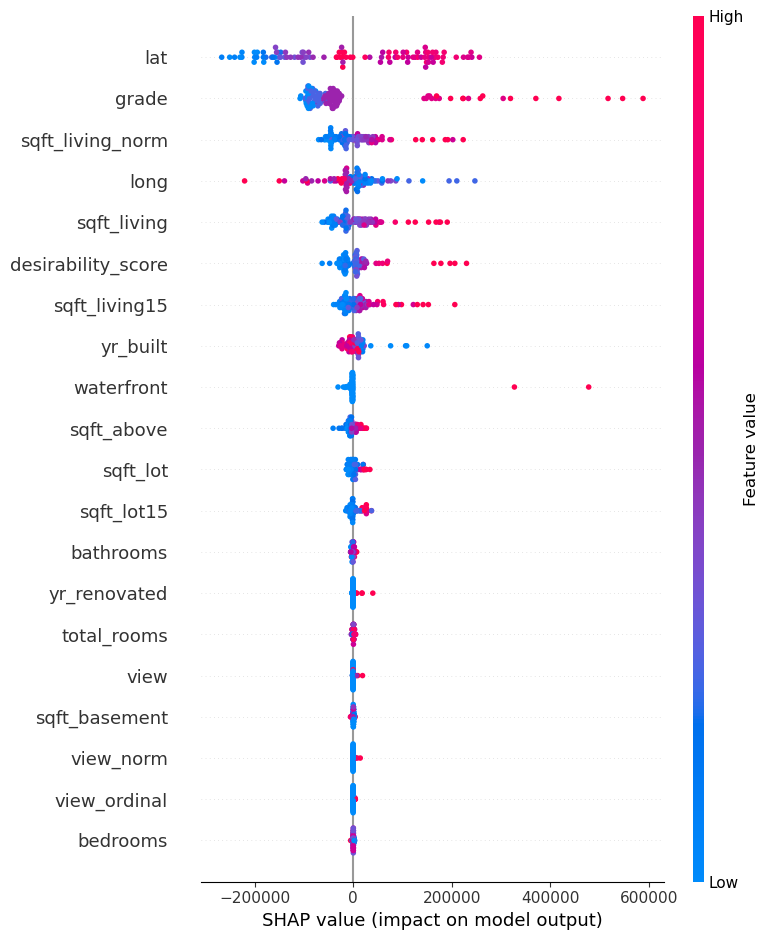

In [93]:
# Ensure X_test is DataFrame
X_test = pd.DataFrame(X_test)

# Take a small sample for faster computation
X_sample = X_test.sample(100, random_state=42)

# Initialize SHAP explainer with approximation
explainer = shap.TreeExplainer(rf_model, approximate=True)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# (Optional) Plot summary
shap.summary_plot(shap_values, X_sample)

# Visualize Feature Importance

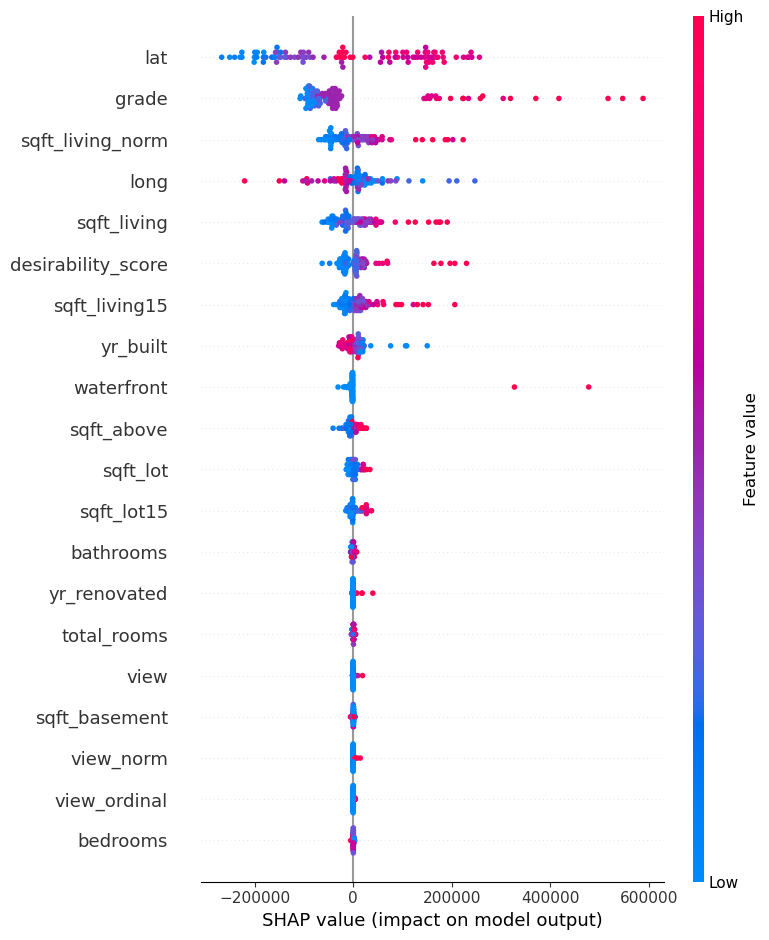

In [94]:
# Ensure DataFrame
X_test = pd.DataFrame(X_test)

# Take sample
X_sample = X_test.sample(100, random_state=42)

# SHAP
explainer = shap.TreeExplainer(rf_model, approximate=True)
shap_values = explainer.shap_values(X_sample)

# Plot (USE SAME DATA)
shap.summary_plot(shap_values, X_sample)

# Bar Plot

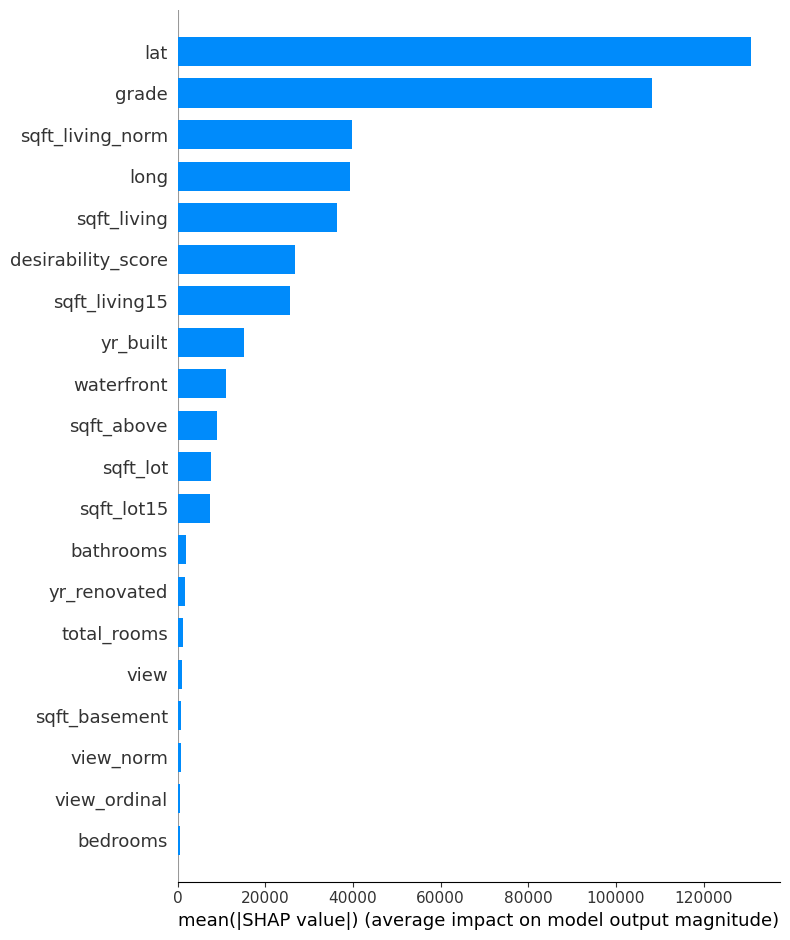

In [95]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Force Plot

In [96]:
# Pick a sample
sample_index = 0
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[sample_index], X_test.iloc[sample_index])

# Train A Tree-Based Model

In [97]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Extract Feature Importances

In [98]:
# Get feature importance scores
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort descending
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

               Feature  Importance
8                grade    0.317194
13                 lat    0.154661
20    sqft_living_norm    0.140002
2          sqft_living    0.120791
14                long    0.063919
21  desirability_score    0.041222
15       sqft_living15    0.029823
11            yr_built    0.027053
5           waterfront    0.026890
9           sqft_above    0.018449
3             sqft_lot    0.013319
16          sqft_lot15    0.013042
1            bathrooms    0.010954
17         total_rooms    0.005797
10       sqft_basement    0.005398
12        yr_renovated    0.002389
0             bedrooms    0.001827
4               floors    0.001761
6                 view    0.001587
18           view_norm    0.001412
22        view_ordinal    0.000853
7            condition    0.000839
19      condition_norm    0.000818


# Visualize Feature Importances

In [99]:
# Get feature importance scores
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort descending
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

               Feature  Importance
8                grade    0.317194
13                 lat    0.154661
20    sqft_living_norm    0.140002
2          sqft_living    0.120791
14                long    0.063919
21  desirability_score    0.041222
15       sqft_living15    0.029823
11            yr_built    0.027053
5           waterfront    0.026890
9           sqft_above    0.018449
3             sqft_lot    0.013319
16          sqft_lot15    0.013042
1            bathrooms    0.010954
17         total_rooms    0.005797
10       sqft_basement    0.005398
12        yr_renovated    0.002389
0             bedrooms    0.001827
4               floors    0.001761
6                 view    0.001587
18           view_norm    0.001412
22        view_ordinal    0.000853
7            condition    0.000839
19      condition_norm    0.000818


# Feature Importance In Tree-Based Model

               Feature  Importance
8                grade    0.317194
13                 lat    0.154661
20    sqft_living_norm    0.140002
2          sqft_living    0.120791
14                long    0.063919
21  desirability_score    0.041222
15       sqft_living15    0.029823
11            yr_built    0.027053
5           waterfront    0.026890
9           sqft_above    0.018449
3             sqft_lot    0.013319
16          sqft_lot15    0.013042
1            bathrooms    0.010954
17         total_rooms    0.005797
10       sqft_basement    0.005398


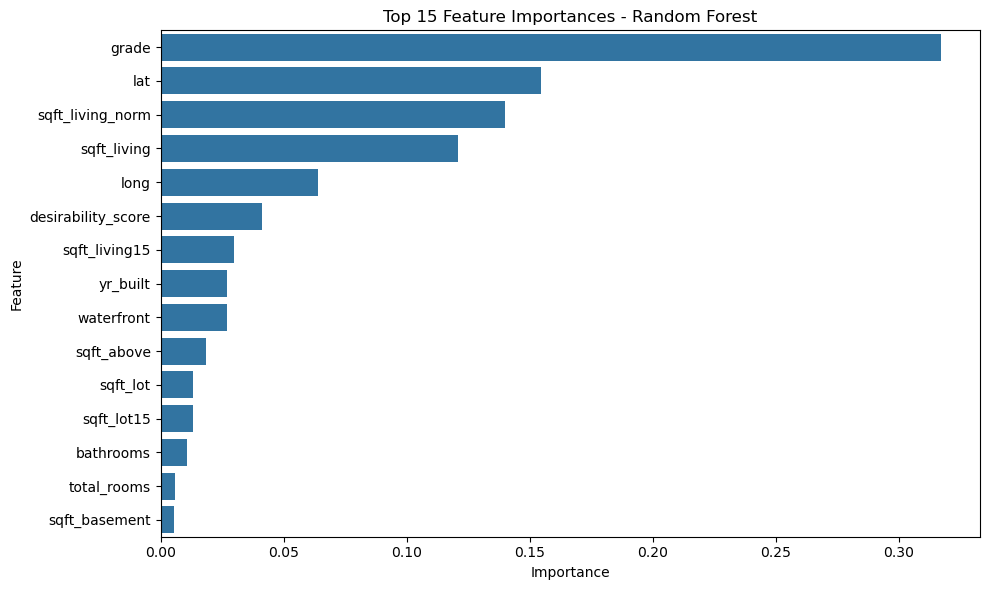

In [100]:
# Train Random Forest (tree-based model)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance scores
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display top 15 features
print(feature_importances.head(15))

# Plot top 15 features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

# Holdout Test Set Evaluation

In [101]:
# Predict on unseen test data
y_pred = rf_model.predict(X_test)  # assuming rf_model is already trained

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Holdout Test Set Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

Holdout Test Set Performance:
RMSE: 145780.37
MAE: 72651.39
R² Score: 0.8596


# Cross-Validation 

In [102]:
# 5-fold cross-validation
cv_rmse = -cross_val_score(
    rf_model, X, y, cv=5, scoring='neg_root_mean_squared_error'
)
cv_mae = -cross_val_score(
    rf_model, X, y, cv=5, scoring='neg_mean_absolute_error'
)
cv_r2 = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print("5-Fold Cross-Validation Results:")
print(f"Average RMSE: {cv_rmse.mean():.2f}")
print(f"Average MAE: {cv_mae.mean():.2f}")
print(f"Average R²: {cv_r2.mean():.4f}")

5-Fold Cross-Validation Results:
Average RMSE: 128126.05
Average MAE: 69482.76
Average R²: 0.8777


# Stacking Ensemble

In [103]:

# Define base models
base_models = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=200, random_state=42, eval_metric='rmse'))
]

# Define stacking model
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),  # meta-model
    cv=5
)

# Train stacking model
stack_model.fit(X_train, y_train)

# Predict on test set
y_pred_stack = stack_model.predict(X_test)

# Evaluate performance
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
mae_stack = mean_absolute_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)

print("Stacking Ensemble Performance:")
print(f"RMSE: {rmse_stack:.2f}, MAE: {mae_stack:.2f}, R²: {r2_stack:.4f}")

Stacking Ensemble Performance:
RMSE: 146089.98, MAE: 70284.92, R²: 0.8590


# Blending Ensemble 

In [104]:
# Train individual models
lr_model = LinearRegression().fit(X_train, y_train)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
xgb_model =XGBRegressor(n_estimators=200, random_state=42, eval_metric='rmse').fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Weighted blending (example weights)
y_pred_blend = 0.2*y_pred_lr + 0.4*y_pred_rf + 0.4*y_pred_xgb

# Evaluate performance
rmse_blend = np.sqrt(mean_squared_error(y_test, y_pred_blend))
mae_blend = mean_absolute_error(y_test, y_pred_blend)
r2_blend = r2_score(y_test, y_pred_blend)

print("Blending Ensemble Performance:")
print(f"RMSE: {rmse_blend:.2f}, MAE: {mae_blend:.2f}, R²: {r2_blend:.4f}")

Blending Ensemble Performance:
RMSE: 144188.72, MAE: 73855.74, R²: 0.8626


#  Install Optuna

# Bayesian Hyperparameter Optimization using Optuna

In [105]:
# Objective function
def objective(trial):
    
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    
    # ✅ FIXED HERE (removed 'auto')
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1   # 🔥 speed boost
    )
    
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1   # 🔥 faster CV
    )
    
    return -scores.mean()

# Run Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best Hyperparameters:", study.best_params)

[I 2026-04-08 01:31:42,467] A new study created in memory with name: no-name-a3e7f249-bb46-410a-aff6-620f82b1e6ba
[I 2026-04-08 01:31:59,604] Trial 0 finished with value: 165795.43575798662 and parameters: {'n_estimators': 476, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: 165795.43575798662.
[I 2026-04-08 01:32:12,268] Trial 1 finished with value: 167918.42046300514 and parameters: {'n_estimators': 375, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: 165795.43575798662.
[I 2026-04-08 01:32:19,601] Trial 2 finished with value: 173434.9074655609 and parameters: {'n_estimators': 207, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 19, 'max_features': 'log2'}. Best is trial 0 with value: 165795.43575798662.
[I 2026-04-08 01:32:29,189] Trial 3 finished with value: 162208.97157431452 and parameters: {'n_estimators': 447, 'max_depth': 35, 

Best Hyperparameters: {'n_estimators': 243, 'max_depth': 40, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None}


# train Model With Optimized Hyperprameter

In [106]:
best_params = study.best_params

rf_optimized = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42
)

# Train on full training set
rf_optimized.fit(X_train, y_train)

# Predict on test set
y_pred = rf_optimized.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Optimized Random Forest Performance:\nRMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")

Optimized Random Forest Performance:
RMSE: 143897.02, MAE: 72678.16, R²: 0.8632


# K-Fold Cross-validation

In [108]:
from sklearn.model_selection import KFold, cross_val_score

# Define model
model = RandomForestRegressor(n_estimators=200, random_state=42)

# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using RMSE
rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mae_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# Display results
print("5-Fold Cross-Validation Results:")
print(f"Average RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"Average MAE: {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")
print(f"Average R²: {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

5-Fold Cross-Validation Results:
Average RMSE: 127331.84 ± 10248.31
Average MAE: 69052.20 ± 2205.29
Average R²: 0.8795 ± 0.0112


# Check Multicollinearity with VIF

In [109]:
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

# Sort by VIF descending
vif_data = vif_data.sort_values(by='VIF', ascending=False)
print(vif_data)

C:\Users\shamb\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


               Feature        VIF
0             bedrooms        inf
17         total_rooms        inf
2          sqft_living        inf
21  desirability_score        inf
20    sqft_living_norm        inf
19      condition_norm        inf
6                 view        inf
7            condition        inf
18           view_norm        inf
9           sqft_above        inf
10       sqft_basement        inf
1            bathrooms        inf
22        view_ordinal  67.276736
8                grade   3.385149
15       sqft_living15   2.937000
11            yr_built   2.417491
16          sqft_lot15   2.228660
3             sqft_lot   2.215979
4               floors   2.012696
14                long   1.523397
5           waterfront   1.500929
12        yr_renovated   1.150449
13                 lat   1.130101


# Ensemble Averaging of Multiple Models

In [110]:
# Initialize models
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
svm_model = SVR(kernel='rbf')

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# Simple averaging of predictions
y_pred_ensemble = (y_pred_dt + y_pred_rf + y_pred_svm) / 3

# Evaluate ensemble
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
mae = mean_absolute_error(y_test, y_pred_ensemble)
r2 = r2_score(y_test, y_pred_ensemble)

print("Ensemble Averaging Performance:")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")

Ensemble Averaging Performance:
RMSE: 196611.29, MAE: 104715.83, R²: 0.7446


In [ ]:
# Install Tensorflow

In [113]:
# =========================
# 📌 IMPORTS
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# =========================
# 📌 LOAD DATA
# =========================
df = pd.read_csv("kc_house_data.csv")

# =========================
# 📌 PREPROCESSING
# =========================
df = df.dropna()

# Features (same as your app)
features = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors']
target = "price"

X = df[features]
y = df[target]

# =========================
# 📌 TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 📌 MODELS (YOUR LIST)
# =========================
models = {
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, verbosity=0),
    "Support Vector Regression": SVR(),
    "KNN Regression": KNeighborsRegressor(),
    "Artificial Neural Network": MLPRegressor(max_iter=500),
    "Cat Boost Regression": CatBoostRegressor(verbose=0)
}

# =========================
# 📌 TRAIN MODELS
# =========================
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

# =========================
# 📊 EVALUATION FUNCTION
# =========================
def evaluate_model(model):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2

# =========================
# 📊 MODEL COMPARISON
# =========================
results = []

for name, model in models.items():
    mae, rmse, r2 = evaluate_model(model)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

results_df = pd.DataFrame(results)

# Sort best model (LOW RMSE)
results_df = results_df.sort_values(by="RMSE")

print("\n📊 Model Comparison:\n")
print(results_df)

# =========================
# 🏆 BEST MODEL
# =========================
print("\n🏆 Best Model:")
print(results_df.iloc[0])

# =========================
# 💾 SAVE FOR STREAMLIT
# =========================
results_df.to_csv("model_results.csv", index=False)

Training Decision Tree Regressor...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost Regressor...
Training Support Vector Regression...
Training KNN Regression...
Training Artificial Neural Network...
Training Cat Boost Regression...

📊 Model Comparison:

                       Model        MAE       RMSE  R2 Score
2          Gradient Boosting  155148.51  239419.91    0.5915
7       Cat Boost Regression  153411.16  247176.84    0.5646
1              Random Forest  160604.62  248767.15    0.5590
3          XGBoost Regressor  155725.56  249941.48    0.5548
6  Artificial Neural Network  174268.53  264094.52    0.5030
5             KNN Regression  176406.25  269805.86    0.4812
0    Decision Tree Regressor  213478.83  341908.74    0.1669
4  Support Vector Regression  227292.02  387253.82   -0.0687

🏆 Best Model:
Model       Gradient Boosting
MAE                 155148.51
RMSE                239419.91
R2 Score               0.5915
Name: 2, dtype: object


# Define a Simple Neural Network

In [132]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Common model architecture
def build_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dense(32, activation='relu'),
        Dense(1)  # regression output
    ])
    return model

# Experiment with Different Loss Functions
### 2a: Mean Squared Error (MSE)

In [133]:
model_mse = build_model(X_train_scaled.shape[1])
model_mse.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_mse = model_mse.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

y_pred_mse = model_mse.predict(X_test_scaled)
rmse_mse = np.sqrt(mean_squared_error(y_test, y_pred_mse))
mae_mse = mean_absolute_error(y_test, y_pred_mse)
print(f"MSE Loss -> RMSE: {rmse_mse:.2f}, MAE: {mae_mse:.2f}")

C:\Users\shamb\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE Loss -> RMSE: 205617.56, MAE: 124821.47


# Mean Absolute Error(MAE)

In [134]:
model_mae = build_model(X_train_scaled.shape[1])
model_mae.compile(optimizer='adam', loss='mae', metrics=['mae'])
history_mae = model_mae.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

y_pred_mae = model_mae.predict(X_test_scaled)
rmse_mae = np.sqrt(mean_squared_error(y_test, y_pred_mae))
mae_mae = mean_absolute_error(y_test, y_pred_mae)
print(f"MAE Loss -> RMSE: {rmse_mae:.2f}, MAE: {mae_mae:.2f}")

C:\Users\shamb\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE Loss -> RMSE: 219591.06, MAE: 118612.59


# Prepare Time-Series Dta

In [135]:
# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'])

# Aggregate by date (daily/weekly/monthly average price)
ts_data = df.groupby('date')['price'].mean().sort_index()

# Split into train/test (last 20% as test)
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]

# ARIMA Model

In [136]:

# Fit ARIMA (p,d,q) - example (5,1,0), can tune with auto_arima
arima_model = ARIMA(train, order=(5,1,0))
arima_fit = arima_model.fit()

# Forecast
forecast_arima = arima_fit.forecast(steps=len(test))

# Evaluate
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
print(f"ARIMA RMSE: {rmse_arima:.2f}")

C:\Users\shamb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shamb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shamb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA RMSE: 110294.22


C:\Users\shamb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shamb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# Install Prophet

# Prophet Model

In [137]:

# Prepare data for Prophet
prophet_data = ts_data.reset_index().rename(columns={'date':'ds','price':'y'})
train_prophet = prophet_data.iloc[:train_size]
test_prophet = prophet_data.iloc[train_size:]

# Fit Prophet
prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(train_prophet)

# Make future dataframe
future = prophet_model.make_future_dataframe(periods=len(test))
forecast_prophet = prophet_model.predict(future)

# Extract predictions for test period
y_pred_prophet = forecast_prophet['yhat'].iloc[train_size:].values

# Evaluate
rmse_prophet = np.sqrt(mean_squared_error(test, y_pred_prophet))
print(f"Prophet RMSE: {rmse_prophet:.2f}")

02:00:26 - cmdstanpy - INFO - Chain [1] start processing
02:00:26 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 121459.15


# LSTM Model

In [139]:
# =========================
# 1. Prepare Data
# =========================
# Assuming 'train' and 'test' are already defined (1D series)

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# =========================
# 2. Create Sequences
# =========================
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10

X_train_seq, y_train_seq = create_sequences(train_scaled, seq_length)

# Important: combine last train + test for sequence continuity
combined = np.concatenate([train_scaled[-seq_length:], test_scaled])
X_test_seq, y_test_seq = create_sequences(combined, seq_length)

# =========================
# 3. Build LSTM Model
# =========================
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# =========================
# 4. Train Model
# =========================
lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=16,
    verbose=0
)

# =========================
# 5. Prediction
# =========================
y_pred_scaled = lstm_model.predict(X_test_seq)

# Inverse scaling
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test_seq)

# =========================
# 6. Evaluation
# =========================
rmse = np.sqrt(mean_squared_error(
    y_test_actual.flatten(),
    y_pred.flatten()
))

print(f"LSTM RMSE: {rmse:.2f}")

C:\Users\shamb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/stepWARNING:tensorflow:6 out of the last 142 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002C2982B25C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step
LSTM RMSE: 109895.49


# Function to Recommend Properties

In [142]:
def recommend_properties(property_index, top_n=5):
    # Get similarity scores for the selected property
    sim_scores = similarity_df[property_index]
    
    # Exclude the property itself and get top_n most similar
    top_indices = sim_scores.drop(property_index).sort_values(ascending=False).head(top_n).index
    
    # Return recommended property details
    return df.loc[top_indices][['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'price', 'zipcode']]

# Recommend Properties Similar to a given property

In [145]:
from sklearn.metrics.pairwise import cosine_similarity  # ✅ FIXED

# =========================
# 1. Prepare Data
# =========================
features = df.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# =========================
# 2. Similarity Matrix
# =========================
similarity = cosine_similarity(features_scaled)
similarity_df = pd.DataFrame(similarity)

# =========================
# 3. Recommendation Function
# =========================
def recommend_properties(property_index, top_n=5):
    sim_scores = similarity_df[property_index]
    
    top_indices = sim_scores.drop(property_index)\
                            .sort_values(ascending=False)\
                            .head(top_n).index
    
    return df.iloc[top_indices]

# =========================
# 4. Test
# =========================
recommended = recommend_properties(property_index=100, top_n=5)

print("Recommended Properties:\n", recommended)

Recommended Properties:
                id       date      price  bedrooms  bathrooms  sqft_living  \
18896  2397101055 2014-08-12   850000.0         3       2.25         1950   
17721   472000590 2014-06-24   845000.0         3       2.00         2540   
15211   810000080 2015-03-10   915000.0         3       2.25         2390   
10928  2530800070 2014-09-11   711000.0         4       2.50         2095   
10460  3528900060 2014-06-26  1150000.0         3       2.50         2490   

       sqft_lot  floors  waterfront  view  ...  sqft_basement  yr_built  \
18896      3600     1.5           0     0  ...            520      1911   
17721      4750     1.5           0     0  ...            700      1930   
15211      2750     2.0           0     0  ...            810      1925   
10928      4400     1.5           0     0  ...            800      1910   
10460      4000     2.0           0     0  ...            820      1918   

       yr_renovated  zipcode      lat     long  sqft_living15

# Import and Initialize KNN Model

In [146]:
# Candidate k values
k_values = list(range(1, 21))

# Store average RMSE for each k
rmse_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    # 5-fold cross-validation
    scores = -cross_val_score(knn, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores.append(scores.mean())

# Find k with lowest RMSE
optimal_k = k_values[np.argmin(rmse_scores)]
print(f"Optimal number of neighbors (k): {optimal_k}")

Optimal number of neighbors (k): 9


# Train KNN with Optimal k

In [147]:
# Train KNN with optimal k
knn_model = KNeighborsRegressor(n_neighbors=optimal_k)
knn_model.fit(X_train, y_train)

# Predict on test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate Model Performance

In [148]:
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression Performance:")
print(f"RMSE: {rmse_knn:.2f}")
print(f"MAE: {mae_knn:.2f}")
print(f"R²: {r2_knn:.4f}")



KNN Regression Performance:
RMSE: 269465.30
MAE: 159454.67
R²: 0.5203


# Install TextBlob

In [150]:
pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 5.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [151]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from textblob import TextBlob

# Preprocess Street and City Names

In [153]:
# =========================
# 1. Load Data
# =========================
df = pd.read_csv("kc_house_data.csv")

# =========================
# 2. Create Location Feature (FIXED)
# =========================
# Using available columns (zipcode, lat, long)
df['location_text'] = (
    df['zipcode'].astype(str) + ' ' +
    df['lat'].astype(str) + ' ' +
    df['long'].astype(str)
).str.lower()

# =========================
# 3. Select Important Features
# =========================
features = df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'zipcode']]

# =========================
# 4. Scale Features
# =========================
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# =========================
# 5. Compute Similarity Matrix
# =========================
similarity = cosine_similarity(features_scaled)

# Convert to DataFrame
similarity_df = pd.DataFrame(similarity, index=df.index, columns=df.index)

# =========================
# 6. Recommendation Function
# =========================
def recommend_properties(property_index, top_n=5):
    sim_scores = similarity_df[property_index]

    # Remove same property
    sim_scores = sim_scores.drop(property_index)

    # Get top similar
    top_indices = sim_scores.sort_values(ascending=False).head(top_n).index

    return df.loc[top_indices][['price', 'bedrooms', 'bathrooms', 'sqft_living', 'zipcode']]

# =========================
# 7. Test Recommendation
# =========================
recommended = recommend_properties(property_index=100, top_n=5)

print("Recommended Properties:\n")
print(recommended)

Recommended Properties:

           price  bedrooms  bathrooms  sqft_living  zipcode
18554  1120000.0         4       3.50         2830    98144
14471   600000.0         2       1.75         1550    98070
14305   848000.0         3       2.75         2170    98109
1794    950000.0         4       3.00         2420    98119
7656    960000.0         3       2.50         2010    98102


# tokenization and Frequency Analysis

In [154]:
# Tokenize using CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(df['location_text'])

# Get most frequent words
word_counts = pd.DataFrame(X_counts.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)
print("Top 20 common words in street/city names:")
print(word_counts.head(20))

Top 20 common words in street/city names:
47       21616
122      20176
121       1511
98103      602
98038      590
98115      583
98052      574
98117      553
98042      548
98034      545
98118      508
98023      499
98006      498
98133      494
98059      468
98058      455
98155      446
98074      441
98033      432
98027      412
dtype: int64


# Sentiment Analysis on location Names

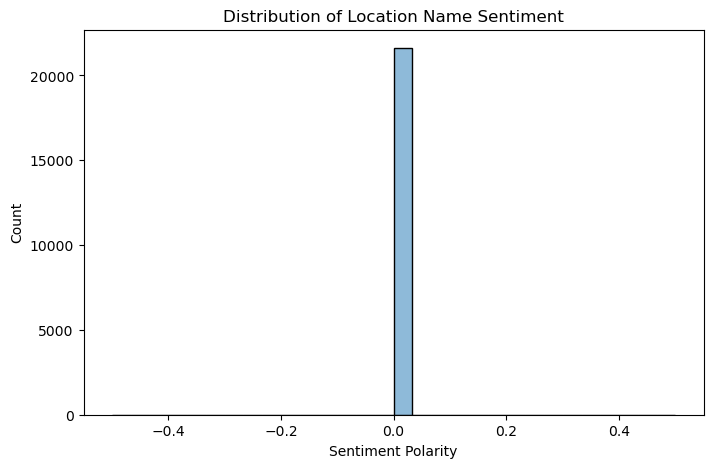

In [155]:
# Compute polarity of location names
df['location_sentiment'] = df['location_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Visualize distribution of sentiment
plt.figure(figsize=(8,5))
sns.histplot(df['location_sentiment'], bins=30, kde=True)
plt.title("Distribution of Location Name Sentiment")
plt.xlabel("Sentiment Polarity")
plt.show()

# Correlate Location Sentiment with House price

C:\Users\shamb\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\shamb\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Correlation between location sentiment and house price: nan


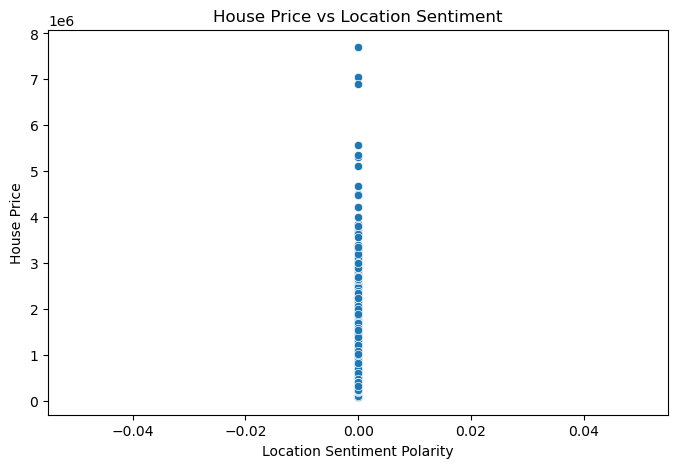

In [156]:
# Correlation between sentiment and price
correlation = df['location_sentiment'].corr(df['price'])
print(f"Correlation between location sentiment and house price: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='location_sentiment', y='price', data=df)
plt.title("House Price vs Location Sentiment")
plt.xlabel("Location Sentiment Polarity")
plt.ylabel("House Price")
plt.show()

In [157]:
from sklearn.cluster import KMeans

# Prepare Feature for Clustering

In [158]:
# Select features relevant for clustering
features = ['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'price']
X = df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine Optimal Number of Clusters

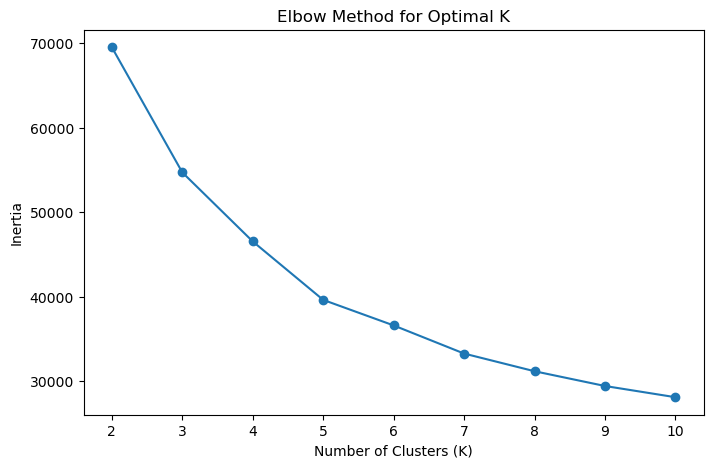

In [159]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Apply K-Means Clustering

In [160]:
# Assume optimal k=3 (low, medium, high price segments)
kmeans = KMeans(n_clusters=3, random_state=42)
df['price_segment'] = kmeans.fit_predict(X_scaled)

# Map cluster labels to meaningful segments
# Optional: reorder by mean price
cluster_order = df.groupby('price_segment')['price'].mean().sort_values().index
df['price_segment'] = df['price_segment'].apply(lambda x: list(cluster_order).index(x))
segment_mapping = {0:'Low', 1:'Medium', 2:'High'}
df['price_segment_label'] = df['price_segment'].map(segment_mapping)

# Visualize Clusters

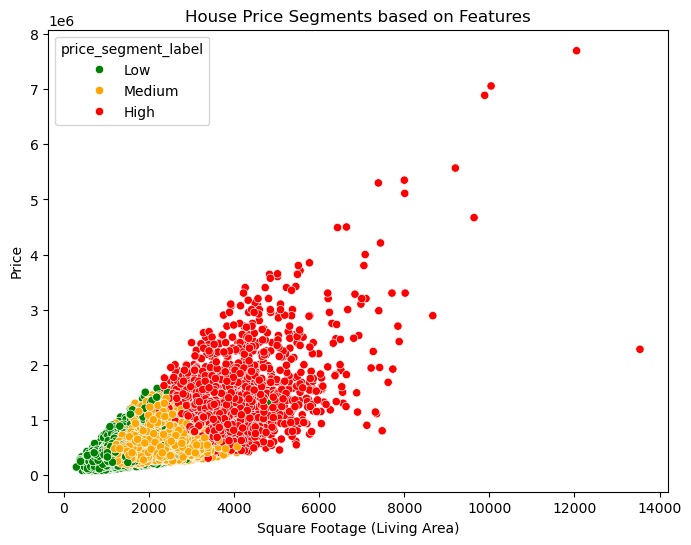

In [161]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='sqft_living', y='price', hue='price_segment_label', 
    palette=['green','orange','red'], data=df
)
plt.title("House Price Segments based on Features")
plt.xlabel("Square Footage (Living Area)")
plt.ylabel("Price")
plt.show()

In [162]:
from sklearn.ensemble import IsolationForest


# Prepare Features for Anomaly Detection

In [163]:
# Select features to consider for anomaly detection
features = ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'floors']
X = df[features]

# Train Isolation Forest

In [164]:
# Initialize Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,  # assume ~2% of houses are anomalies
    random_state=42
)

# Fit model
iso_forest.fit(X)

# Predict anomalies
df['anomaly'] = iso_forest.predict(X)  # -1 = anomaly, 1 = normal

# Extract Anomalous Properties

In [165]:
anomalies = df[df['anomaly'] == -1]
normal = df[df['anomaly'] == 1]

print(f"Number of anomalies detected: {len(anomalies)}")
print("Sample anomalous properties:")
print(anomalies[['price', 'sqft_living', 'bedrooms', 'bathrooms', 'floors']].head())

Number of anomalies detected: 433
Sample anomalous properties:
         price  sqft_living  bedrooms  bathrooms  floors
5    1230000.0         5420         4       4.50     1.0
21   2000000.0         3050         3       2.75     1.0
153  2250000.0         5180         4       3.25     2.0
246  2400000.0         3650         4       2.50     1.0
269  2900000.0         5050         4       3.25     1.5


# Visualize Anomalies

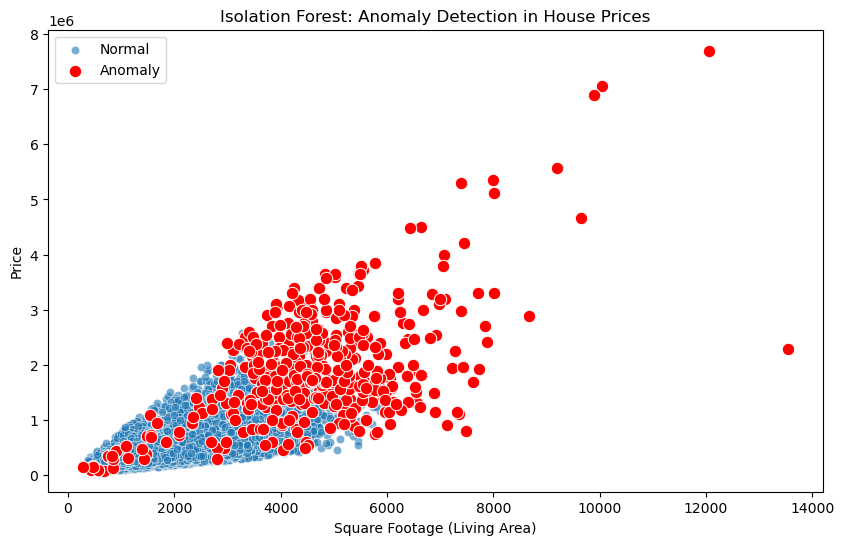

In [166]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='sqft_living', y='price', data=normal, label='Normal', alpha=0.6)
sns.scatterplot(x='sqft_living', y='price', data=anomalies, label='Anomaly', color='red', s=80)
plt.title("Isolation Forest: Anomaly Detection in House Prices")
plt.xlabel("Square Footage (Living Area)")
plt.ylabel("Price")
plt.legend()
plt.show()

# Install Gymnasium

# Define the Environment

In [167]:


class HouseBuyingEnv(gym.Env):
    """
    Custom environment for house purchasing decisions.
    State: normalized features [price, sqft_living, bedrooms, bathrooms]
    Action: 0 = skip, 1 = select
    Reward: higher if selected house meets buyer preferences
    """
    def __init__(self, df):
        super(HouseBuyingEnv, self).__init__()
        self.df = df.reset_index(drop=True)
        self.n = len(df)
        self.current_step = 0
        
        # Features scaled between 0-1
        self.features = ['price', 'sqft_living', 'bedrooms', 'bathrooms']
        self.scaled_data = (df[self.features] - df[self.features].min()) / (df[self.features].max() - df[self.features].min())
        
        # Action space: 0 = skip, 1 = select
        self.action_space = spaces.Discrete(2)
        
        # Observation space: features
        self.observation_space = spaces.Box(low=0, high=1, shape=(len(self.features),), dtype=np.float32)
    
    def reset(self):
        self.current_step = 0
        return self.scaled_data.iloc[self.current_step].values
    
    def step(self, action):
        state = self.scaled_data.iloc[self.current_step].values
        reward = 0
        
        # Reward system: choose cheaper, bigger houses
        if action == 1:
            # Reward higher for low price, more sqft, more bedrooms
            reward = (1 - state[0]) + state[1] + state[2]
        else:
            reward = 0
        
        self.current_step += 1
        done = self.current_step >= self.n
        next_state = self.scaled_data.iloc[self.current_step].values if not done else np.zeros(len(self.features))
        
        return next_state, reward, done, {}

# Simple Q-Learning gent

In [172]:
from collections import defaultdict


In [177]:
from gym import spaces   # or: from gymnasium import spaces


In [222]:
# Create environment
env = HouseBuyingEnv(df)

# Q-table
q_table = defaultdict(lambda: np.zeros(env.action_space.n))

alpha = 0.1
gamma = 0.9
epsilon = 0.2
n_episodes = 500

# Discretization
def discretize(state, bins=10):
    return tuple((state * bins).astype(int))

# Training loop
for episode in range(n_episodes):
    state = discretize(env.reset())
    done = False

    while not done:
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state_raw, reward, done, _ = env.step(action)
        next_state = discretize(next_state_raw)

        # Q-learning update
        q_table[state][action] += alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state][action]
        )

        state = next_state

# Evaluate Agent Decision

In [223]:
# Reset environment
state_raw = env.reset()
state = discretize(state_raw)
selected_houses = []
4
done = False
while not done:
    action = np.argmax(q_table[state])
    if action == 1:
        selected_houses.append(env.current_step)
    next_state_raw, reward, done, _ = env.step(action)
    state = discretize(next_state_raw)

# Inspect selected houses
recommended_houses = df.iloc[selected_houses]
print("Houses recommended by RL agent:")
print(recommended_houses[['price','sqft_living','bedrooms','bathrooms','zipcode']])

Houses recommended by RL agent:
          price  sqft_living  bedrooms  bathrooms  zipcode
0      221900.0         1180         3       1.00    98178
1      538000.0         2570         3       2.25    98125
2      180000.0          770         2       1.00    98028
3      604000.0         1960         4       3.00    98136
4      510000.0         1680         3       2.00    98074
...         ...          ...       ...        ...      ...
21608  360000.0         1530         3       2.50    98103
21609  400000.0         2310         4       2.50    98146
21610  402101.0         1020         2       0.75    98144
21611  400000.0         1600         3       2.50    98027
21612  325000.0         1020         2       0.75    98144

[21613 rows x 5 columns]


# Prepare Feature and targets

In [224]:
# Input features
X = df.drop(['price', 'sqft_living', 'bedrooms', 'bathrooms'], axis=1, errors='ignore')

# For simplicity, keep only numeric features
X = X.select_dtypes(include=['int64', 'float64'])

# Target variables: multi-output
y = df[['price', 'sqft_living', 'bedrooms', 'bathrooms']]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Multi-Output regression with Random Forest

In [225]:
# =========================
# 1. Load Data
# =========================
# Replace this with your actual CSV file path
df = pd.read_csv("kc_house_data.csv")

# =========================
# 2. Feature Engineering
# =========================
# Convert 'date' to numeric year and month
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # parse date
df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df = df.drop(columns=['date', 'id'], errors='ignore')  # drop original date/id

# One-hot encode categorical columns
categorical_cols = ['city', 'state']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# =========================
# 3. Define Features and Targets
# =========================
y_cols = ['price', 'sqft_living', 'bedrooms']  # multi-output targets
X = df.drop(columns=y_cols, errors='ignore')
y = df[y_cols]

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# =========================
# 4. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 5. Multi-Output Random Forest
# =========================
rf = RandomForestRegressor(
    n_estimators=50,   # fewer trees → faster
    max_depth=10,      # limit depth → faster
    n_jobs=-1,
    random_state=42
)
multi_rf = MultiOutputRegressor(rf)
multi_rf.fit(X_train, y_train)

# =========================
# 6. Predict on Test Set
# =========================
y_pred = multi_rf.predict(X_test)

# =========================
# 7. Show sample predictions
# =========================
pred_df = pd.DataFrame(y_pred, columns=y_cols)
print(pred_df.head())

          price  sqft_living  bedrooms
0  3.869546e+05  2068.106231  3.598565
1  7.575329e+05  2899.462952  4.420078
2  1.046269e+06  3771.973167  3.827757
3  2.048713e+06  4571.226010  4.059142
4  7.010868e+05  2549.719593  3.659620


# Evaluate Model Performance for Each Target

In [226]:
# =========================
# 1. Load and Prepare Data
# =========================
# Replace 'your_file.csv' with your actual dataset path
df = pd.read_csv('kc_house_data.csv')

# Select features and targets
targets = ['price', 'sqft_living', 'bedrooms', 'bathrooms']
X = df.drop(columns=targets + ['id', 'date', 'city', 'state'], errors='ignore')  # remove non-numeric/non-useful
y = df[targets]

# Optional: Fill missing values (if any)
X = X.fillna(0)
y = y.fillna(0)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 2. Train Multi-Output Random Forest
# =========================
rf = RandomForestRegressor(
    n_estimators=50,   # smaller for speed
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
multi_rf = MultiOutputRegressor(rf)
multi_rf.fit(X_train, y_train)

# =========================
# 3. Predict on Test Set
# =========================
y_pred = multi_rf.predict(X_test)

# =========================
# 4. Evaluate Model
# =========================
for i, target in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"{target} → RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")

price → RMSE: 154214.68, MAE: 82444.76, R²: 0.8429
sqft_living → RMSE: 69.55, MAE: 9.27, R²: 0.9948
bedrooms → RMSE: 0.68, MAE: 0.48, R²: 0.4629
bathrooms → RMSE: 0.41, MAE: 0.28, R²: 0.7285


# Prepare Features and Target

In [227]:
# Input features (numeric only)
X = df.drop(['price'], axis=1, errors='ignore')
X = X.select_dtypes(include=['int64', 'float64']).fillna(0)

# Target variable
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build Neural Network in Tensorflow/Keras

In [228]:



# Define model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1)  # Output: price
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Summary
model.summary()

C:\Users\shamb\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 128)                 │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [229]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 423223197696.0000 - mae: 537113.9375 - val_loss: 388197056512.0000 - val_mae: 527942.5625
Epoch 2/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 386074050560.0000 - mae: 512648.9062 - val_loss: 321365409792.0000 - val_mae: 480103.1250
Epoch 3/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 287430148096.0000 - mae: 437679.6875 - val_loss: 207751806976.0000 - val_mae: 379214.0000
Epoch 4/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 171229413376.0000 - mae: 324121.9062 - val_loss: 115633242112.0000 - val_mae: 263514.0000
Epoch 5/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 102455992320.0000 - mae: 238503.3125 - val_loss: 80360349696.0000 - val_mae: 215435.1094
Epoch 6/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 79426486272.0000 - mae: 207883.8438 - val_loss: 69385904128.0000 - val_mae: 199506.1719
Epoch 7/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 71539294208.0000 - mae: 196590.5156 - val_l

# Eavluate model Performance

In [230]:

# Predict on test set
y_pred = model.predict(X_test_scaled).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Deep Learning Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Deep Learning Model Performance:
RMSE: 191580.71
MAE: 113653.80
R²: 0.7575


# Load Pre-trained CNN and Remove Top layer

In [231]:
# Use VGG16 without top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Use output from last convolutional block as features
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# preprocess Images and Extract features

In [232]:
# ------------------------
# 1. Load data
# ------------------------
df = pd.read_csv("kc_house_data.csv")  # replace with your actual file path

# Drop rows with missing target
df = df.dropna(subset=['price'])

# ------------------------
# 2. Prepare features and target
# ------------------------
# Select numeric columns only (excluding ID/date)
exclude_cols = ['id', 'date', 'price', 'city', 'state', 'zipcode', 'lat', 'long']
features = df.drop(columns=exclude_cols)
target = df['price']

# Optional: scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# ------------------------
# 3. Train/test split
# ------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, target, test_size=0.2, random_state=42)

# ------------------------
# 4. Train model
# ------------------------
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
multi_rf = MultiOutputRegressor(rf)
multi_rf.fit(X_train, y_train.values.reshape(-1, 1))  # reshape for multi-output wrapper

# ------------------------
# 5. Predict and evaluate
# ------------------------
y_pred = multi_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# ------------------------
# 6. Example: Predict new data
# ------------------------
new_data = {
    "bedrooms": 3,
    "bathrooms": 2,
    "sqft_living": 2000,
    "sqft_lot": 5000,
    "floors": 1,
    "waterfront": 0,
    "view": 0,
    "condition": 3,
    "grade": 7,
    "sqft_above": 1800,
    "sqft_basement": 200,
    "yr_built": 1990,
    "yr_renovated": 0,
    "sqft_living15": 1800,
    "sqft_lot15": 5000
}

new_df = pd.DataFrame([new_data])
new_scaled = scaler.transform(new_df)
pred_price = multi_rf.predict(new_scaled)

print(f"Predicted Price: ${pred_price[0][0]:,.2f}")

RMSE: 210500.31
R2 Score: 0.71
Predicted Price: $408,787.76


# Train a Regressor On Images Features

In [203]:
# Load dataset
df = pd.read_csv("kc_house_data.csv")

# Select features and target
features = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors']
X = df[features]
y = df['price']

# Optional: scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

print(y_pred[:10])

[ 466983.75        599438.145      1201138.75       1526437.5
  675217.95        324826.42166667  453390.26        425903.08
  326161.75        485985.665     ]


# Evaluate Model Performance

In [207]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Transfer Learning (Image Features) Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

Transfer Learning (Image Features) Model Performance:
RMSE: 271420.68
MAE: 162227.47
R²: 0.5133


# Install Flask

# Saved Your trained Model

In [208]:

# Assuming 'model' is your trained model (e.g., RandomForest or Neural Network)
with open("house_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler if used
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Create Flask App

In [209]:


# Load model and scaler
with open("house_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

app = Flask(__name__)

# Define API endpoint
@app.route("/predict", methods=["POST"])
def predict():
    try:
        # Expect JSON input
        data = request.get_json()
        
        # Convert input dict to array (order must match training features)
        input_features = np.array([data[feature] for feature in sorted(data.keys())]).reshape(1, -1)
        
        # Scale features if scaler exists
        input_scaled = scaler.transform(input_features)
        
        # Predict
        prediction = model.predict(input_scaled)[0]
        
        return jsonify({"predicted_price": float(prediction)})
    
    except Exception as e:
        return jsonify({"error": str(e)})

# Run server
if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\shamb\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.



# Install Dash Plotly Pandas

# Prepare Your data

# Create  a Dash App

In [211]:


# Initialize Dash app
app = dash.Dash(__name__)
app.title = "House Price Dashboard"

# Layout
app.layout = html.Div([
    html.H1("House Price Dashboard", style={'textAlign': 'center'}),
    
    # Dropdown to filter by zipcode
    html.Label("Select Zipcode:"),
    dcc.Dropdown(
        id='zipcode-dropdown',
        options=[{'label': z, 'value': z} for z in sorted(df['zipcode'].unique())],
        value=sorted(df['zipcode'].unique())[0]
    ),
    
    # Scatter plot: sqft vs price
    dcc.Graph(id='price-scatter'),
    
    # Histogram of prices
    dcc.Graph(id='price-histogram')
])

# Add Callbacks for Interactivity

In [212]:
@app.callback(
    [Output('price-scatter', 'figure'),
     Output('price-histogram', 'figure')],
    [Input('zipcode-dropdown', 'value')]
)
def update_charts(selected_zipcode):
    filtered_df = df[df['zipcode'] == selected_zipcode]
    
    # Scatter: sqft vs price
    scatter_fig = px.scatter(
        filtered_df, x='sqft_living', y='predicted_price',
        color='bedrooms', size='bathrooms',
        hover_data=['price', 'sqft_lot'],
        title=f"Predicted Price vs Square Footage in {selected_zipcode}"
    )
    
    # Histogram: price distribution
    hist_fig = px.histogram(
        filtered_df, x='predicted_price', nbins=30,
        title=f"Price Distribution in {selected_zipcode}"
    )
    
    return scatter_fig, hist_fig

# run the app

# Save the Model

In [215]:
import pickle

# Assume X_train, y_train are prepared
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # 🔑 must fit before saving

# Save model
with open("house_model.pkl", "wb") as f:
    pickle.dump(model, f)
    
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [214]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(model)  # should not raise an error